```markdown
# Classificação com KNN Manual no Dataset Breast Cancer

Este notebook demonstra a implementação do algoritmo K-Nearest Neighbors do zero, utilizando o dataset Breast Cancer Wisconsin da UCI.
```

In [95]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split


In [96]:
!pip install -q ucimlrepo

In [97]:
!pip install -q scikit-learn

In [98]:
from ucimlrepo import fetch_ucirepo

In [99]:
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

In [100]:
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

print(f"Total de amostras: {len(X)}")

Linhas duplicadas encontradas: 0


### Análise Exploratória Rápida
Antes de treinar o modelo, vamos verificar a distribuição das classes e as primeiras linhas dos dados.

In [101]:
# Visualizar as primeiras linhas
display(X.head())

# Verificar distribuição das classes
print("\nDistribuição das classes no target:")
print(y.value_counts())

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Distribuição das classes no target:
Diagnosis
B            357
M            212
Name: count, dtype: int64


```markdown
## Pré-processamento: Limpeza e Normalização
Vamos verificar a integridade dos dados e garantir que todas as características estejam na mesma escala.
```

In [102]:
# Remover colunas com mais de 50% de valores ausentes
threshold = 0.5 * len(X)
X_cleaned = X.dropna(thresh=threshold, axis=1)

# Informar se algo foi removido
dropped_cols = set(X.columns) - set(X_cleaned.columns)
print(f"Colunas removidas (>50% vazias): {list(dropped_cols) if dropped_cols else 'Nenhuma'}")
print(f"Total de features após limpeza: {X_cleaned.shape[1]}")

Colunas removidas (>50% vazias): Nenhuma

Resumo após normalização (primeiras 5 colunas):


,radius1,texture1,perimeter1,area1,smoothness1
count,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.338222,0.323965,0.332935,0.216920,0.394785
std,0.166787,0.145453,0.167915,0.149274,0.126967
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.223342,0.218465,0.216847,0.117413,0.304595
50%,0.302381,0.308759,0.293345,0.172895,0.390358
75%,0.416442,0.408860,0.416765,0.271135,0.475490
max,1.000000,1.000000,1.000000,1.000000,1.000000


```markdown
> **Nota:** Primeiro faremos o *split* em treino/validação/teste com estratificação e, em seguida, aplicaremos normalização Min-Max usando apenas estatísticas do conjunto de treino (evitando *data leakage*).
```

```markdown
## Preparação dos Dados
Agora que conhecemos os dados, vamos dividi-los em três conjuntos: Treino (para ensinar o modelo), Validação (para escolher o melhor K) e Teste (para avaliação final).
```

In [103]:
# Alvo em formato simples (Series) para facilitar estratificação
y_series = y.squeeze()

# 70% treino, 15% validação, 15% teste (estratificado)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_cleaned, y_series, test_size=0.3, random_state=42, stratify=y_series
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Min-Max fit no treino e apply em validação/teste (sem data leakage)
train_min = X_train.min()
train_range = (X_train.max() - train_min).replace(0, 1)

X_train = (X_train - train_min) / train_range
X_val = (X_val - train_min) / train_range
X_test = (X_test - train_min) / train_range

print(f"Treino: {len(X_train)} ({len(X_train)/len(X_cleaned):.0%})")
print(f"Validação: {len(X_val)} ({len(X_val)/len(X_cleaned):.0%})")
print(f"Teste: {len(X_test)} ({len(X_test)/len(X_cleaned):.0%})")

Tamanho do Treino: 398 (70%)
Tamanho da Validação: 86 (15%)
Tamanho do Teste: 85 (15%)


```markdown
## Implementação do KNN
Implementação manual da classe KNN e funções de métrica.
```

In [104]:
import numpy as np

class KNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def predict(self, X):
        X = np.array(X)
        predictions = [self._predict(x) for x in X]
        return np.array(predictions)

    def _predict(self, x):
        distances = [np.sqrt(np.sum((x - x_train)**2)) for x_train in self.X_train]
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        labels, counts = np.unique(k_nearest_labels, return_counts=True)
        return labels[np.argmax(counts)]

def accuracy_score(y_true, y_pred):
    y_true, y_pred = np.array(y_true).ravel(), np.array(y_pred).ravel()
    return np.mean(y_true == y_pred)

def k_fold_cross_validation(X, y, k_neighbors, n_folds=5):
    X_arr, y_arr = np.array(X), np.array(y).ravel()
    indices = np.arange(len(X_arr))
    np.random.seed(42)
    np.random.shuffle(indices)
    folds = np.array_split(indices, n_folds)

    scores = []
    for i in range(n_folds):
        val_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(n_folds) if j != i])

        model = KNN(k=k_neighbors)
        model.fit(X_arr[train_idx], y_arr[train_idx])
        preds = model.predict(X_arr[val_idx])
        scores.append(accuracy_score(y_arr[val_idx], preds))
    return np.mean(scores)

### 1. Funções de Validação e Métricas
Vamos criar funções para calcular a acurácia e realizar o split de validação cruzada de forma manual.

In [105]:
def accuracy_score_manual(y_true, y_pred):
    # Garante que ambos são arrays unidimensionais
    y_true = np.array(y_true).ravel()
    y_pred = np.array(y_pred).ravel()
    return np.mean(y_true == y_pred)

def k_fold_cross_validation(X, y, k_neighbors, n_folds=5):
    # Converter para numpy para facilitar indexação
    X_arr = np.array(X)
    y_arr = np.array(y).ravel()

    # Gerar índices para os folds
    indices = np.arange(len(X_arr))
    np.random.seed(42)
    np.random.shuffle(indices)
    folds = np.array_split(indices, n_folds)

    scores = []
    for i in range(n_folds):
        # Separar treino e validação para este fold
        val_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(n_folds) if j != i])

        X_train_fold, X_val_fold = X_arr[train_idx], X_arr[val_idx]
        y_train_fold, y_val_fold = y_arr[train_idx], y_arr[val_idx]

        # Treinar e prever
        model = KNN(k=k_neighbors)
        model.fit(X_train_fold, y_train_fold)
        preds = model.predict(X_val_fold)

        # Calcular acurácia
        acc = accuracy_score_manual(y_val_fold, preds)
        scores.append(acc)

    return np.mean(scores)

### 2. Busca pelo Melhor K
Agora, testamos diferentes valores de `k` para identificar qual apresenta o melhor desempenho médio na validação cruzada.

In [106]:
# Definir intervalo de K ímpares baseado no tamanho da validação
n_val = len(X_val)
k_values = [k for k in range(1, n_val + 1) if k % 2 != 0]
val_scores = []

print(f"Iniciando busca pelo melhor K (ímpares de 1 até {max(k_values)}) using Validação...")
for k in k_values:
    model = KNN(k=k)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    acc = accuracy_score_manual(y_val, preds)
    val_scores.append(acc)

# Encontrar o melhor K
best_k = k_values[np.argmax(val_scores)]
print(f"\nMelhor K encontrado: {best_k} com acurácia de {max(val_scores):.4f}")

Iniciando busca pelo melhor K (ímpares de 1 até 85) using Validação...

Melhor K encontrado: 3 com acurácia de 0.9884


### 3. Visualização dos Resultados
Plotamos a acurácia em função de `k` para visualizar o comportamento do modelo.

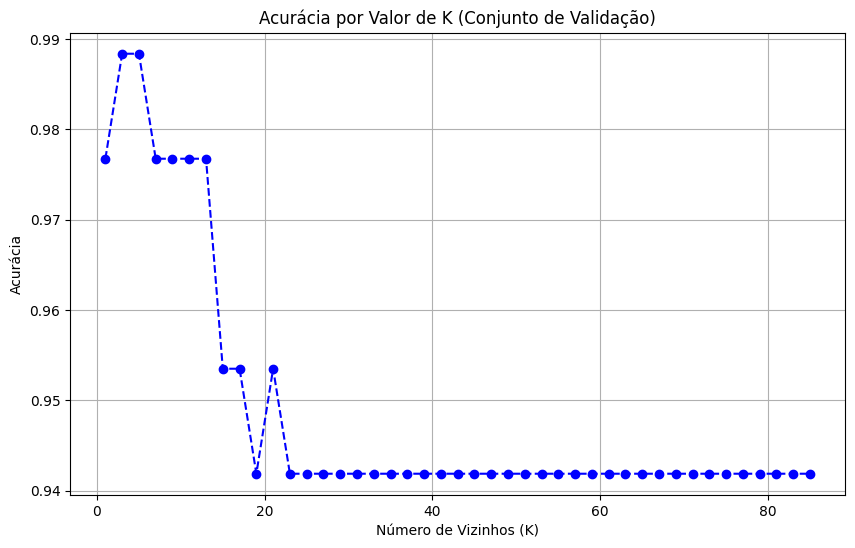

In [107]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# Corrigido para usar val_scores em vez de cv_scores
plt.plot(k_values, val_scores, marker='o', linestyle='--', color='b')
plt.title('Acurácia por Valor de K (Conjunto de Validação)')
plt.xlabel('Número de Vizinhos (K)')
plt.ylabel('Acurácia')
plt.grid(True)
plt.show()

### 4. Avaliação Final no Conjunto de Teste
Utilizamos o `best_k` para treinar o modelo final e avaliar o desempenho real com os dados que o modelo ainda não viu.

In [108]:
# Treino final com TREINO + VALIDAÇÃO (após seleção do melhor K)
X_train_final = pd.concat([X_train, X_val], axis=0)
y_train_final = pd.concat([y_train, y_val], axis=0)

final_clf = KNN(k=best_k)
final_clf.fit(X_train_final, y_train_final)

# Predição no conjunto de TESTE (mantido totalmente separado)
y_pred_final = final_clf.predict(X_test)

# Acurácia final
final_acc = accuracy_score_manual(y_test, y_pred_final)
print(f"--- RESULTADO FINAL ---")
print(f"Acurácia no Teste (k={best_k}): {final_acc:.4f}")

--- RESULTADO FINAL ---
Acurácia no Teste (k=3): 0.9529


In [ ]:
# Verificação de robustez: desempenho em múltiplos random_state
random_states = [0, 7, 21, 42, 99]
accs = []

for rs in random_states:
    # Split estratificado
    X_train_rs, X_temp_rs, y_train_rs, y_temp_rs = train_test_split(
        X_cleaned, y_series, test_size=0.3, random_state=rs, stratify=y_series
    )
    X_val_rs, X_test_rs, y_val_rs, y_test_rs = train_test_split(
        X_temp_rs, y_temp_rs, test_size=0.5, random_state=rs, stratify=y_temp_rs
    )

    # Normalização baseada apenas no treino
    min_rs = X_train_rs.min()
    range_rs = (X_train_rs.max() - min_rs).replace(0, 1)
    X_train_rs = (X_train_rs - min_rs) / range_rs
    X_val_rs = (X_val_rs - min_rs) / range_rs
    X_test_rs = (X_test_rs - min_rs) / range_rs

    # Escolha de K por validação
    k_values_rs = [k for k in range(1, len(X_val_rs) + 1) if k % 2 != 0]
    val_scores_rs = []

    for k in k_values_rs:
        model_rs = KNN(k=k)
        model_rs.fit(X_train_rs, y_train_rs)
        pred_val_rs = model_rs.predict(X_val_rs)
        val_scores_rs.append(accuracy_score_manual(y_val_rs, pred_val_rs))

    best_k_rs = k_values_rs[np.argmax(val_scores_rs)]

    # Treino final com treino + validação
    X_train_final_rs = pd.concat([X_train_rs, X_val_rs], axis=0)
    y_train_final_rs = pd.concat([y_train_rs, y_val_rs], axis=0)

    final_rs = KNN(k=best_k_rs)
    final_rs.fit(X_train_final_rs, y_train_final_rs)
    pred_test_rs = final_rs.predict(X_test_rs)

    acc_rs = accuracy_score_manual(y_test_rs, pred_test_rs)
    accs.append(acc_rs)
    print(f"random_state={rs:>2} | best_k={best_k_rs:>2} | acc_teste={acc_rs:.4f}")

print("\nResumo:")
print(f"Acurácia média = {np.mean(accs):.4f}")
print(f"Desvio padrão   = {np.std(accs):.4f}")

## 5. Fluxo Final Correto de Seleção de K e Acurácia Total

Neste fluxo final:
- o `k` é escolhido no conjunto de validação;
- o modelo final é treinado com `treino + validação`;
- a acurácia final é calculada no conjunto de teste;
- também calculamos a acurácia total média em múltiplos `random_state`.

In [ ]:
def run_knn_pipeline(X_data, y_data, rs=42):
    # 1) Split estratificado
    X_train_p, X_temp_p, y_train_p, y_temp_p = train_test_split(
        X_data, y_data, test_size=0.3, random_state=rs, stratify=y_data
    )
    X_val_p, X_test_p, y_val_p, y_test_p = train_test_split(
        X_temp_p, y_temp_p, test_size=0.5, random_state=rs, stratify=y_temp_p
    )

    # 2) Normalização (fit só no treino)
    min_p = X_train_p.min()
    range_p = (X_train_p.max() - min_p).replace(0, 1)

    X_train_p = (X_train_p - min_p) / range_p
    X_val_p = (X_val_p - min_p) / range_p
    X_test_p = (X_test_p - min_p) / range_p

    # 3) Busca de K no conjunto de validação
    k_vals = [k for k in range(1, len(X_val_p) + 1) if k % 2 != 0]
    val_accs = []

    for k in k_vals:
        m = KNN(k=k)
        m.fit(X_train_p, y_train_p)
        pred_val = m.predict(X_val_p)
        val_accs.append(accuracy_score_manual(y_val_p, pred_val))

    best_k_p = k_vals[np.argmax(val_accs)]
    best_val_acc_p = max(val_accs)

    # 4) Treino final (treino + validação)
    X_train_final_p = pd.concat([X_train_p, X_val_p], axis=0)
    y_train_final_p = pd.concat([y_train_p, y_val_p], axis=0)

    final_model_p = KNN(k=best_k_p)
    final_model_p.fit(X_train_final_p, y_train_final_p)

    # 5) Avaliação final no teste
    y_pred_test_p = final_model_p.predict(X_test_p)
    test_acc_p = accuracy_score_manual(y_test_p, y_pred_test_p)

    return {
        "best_k": best_k_p,
        "val_acc": best_val_acc_p,
        "test_acc": test_acc_p,
    }

# Resultado principal (random_state fixo)
main_result = run_knn_pipeline(X_cleaned, y_series, rs=42)
print("=== RESULTADO FINAL (rs=42) ===")
print(f"Melhor K selecionado: {main_result['best_k']}")
print(f"Acurácia na validação (melhor K): {main_result['val_acc']:.4f}")
print(f"Acurácia FINAL no teste: {main_result['test_acc']:.4f}")

# Acurácia total média (robustez)
states = [0, 7, 21, 42, 99]
all_test_acc = []
all_k = []

for s in states:
    r = run_knn_pipeline(X_cleaned, y_series, rs=s)
    all_test_acc.append(r["test_acc"])
    all_k.append(r["best_k"])
    print(f"rs={s:>2} | best_k={r['best_k']:>2} | acc_final={r['test_acc']:.4f}")

print("\n=== ACURÁCIA TOTAL (MÚLTIPLOS SPLITS) ===")
print(f"Acurácia média final: {np.mean(all_test_acc):.4f}")
print(f"Desvio padrão: {np.std(all_test_acc):.4f}")
print(f"Ks selecionados: {all_k}")

### 6. Matriz de Confusão Manual
Uma forma visual de entender onde o modelo está acertando ou errando.

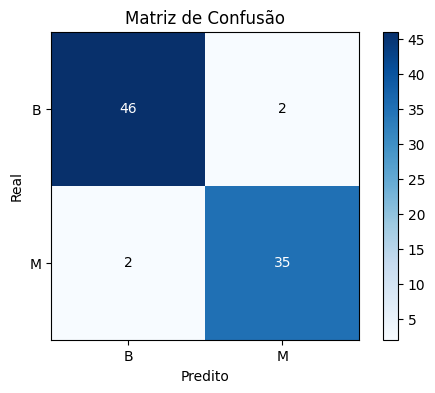

In [109]:
def plot_confusion_matrix_manual(y_true, y_pred, labels):
    y_true = np.array(y_true).ravel()
    y_pred = np.array(y_pred).ravel()

    size = len(labels)
    cm = np.zeros((size, size), dtype=int)

    label_to_idx = {label: i for i, label in enumerate(labels)}

    for t, p in zip(y_true, y_pred):
        cm[label_to_idx[t]][label_to_idx[p]] += 1

    fig, ax = plt.subplots(figsize=(6, 4))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)

    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=labels, yticklabels=labels,
           title='Matriz de Confusão',
           ylabel='Real',
           xlabel='Predito')

    # Adicionar os números dentro dos quadrados
    for i in range(size):
        for j in range(size):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > cm.max()/2 else "black")
    plt.show()

# Extrair labels únicos dos targets
unique_labels = np.unique(y_test)
plot_confusion_matrix_manual(y_test, y_pred_final, unique_labels)